<a href="https://colab.research.google.com/github/vn322/bag_of_bats/blob/main/%D1%82%D0%B5%D0%BE%D1%80%D0%B8%D1%8F_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Теория алгоритмов

**Содержание:**

1. Основные понятия и определения
2. Сложность алгоритма
3. Некоторые классические алгоритмы

## Алгоритмы

Мы слышим слово **алгоритм** в повседневной жизни очень часто.  Обычно под *алгоритмом* понимается некоторая совокупность определенных заранее действий, которую нужно совершить, чтобы прийти к некоторому результату. Алгоритмами являются все написанные людьми программы, поэтому очень важно научиться анализировать алгоритмы, выделять характерные паттерны, прогнозировать и оценивать эффективность тех или иных алгоритмов.

Одна из главных проблем науки о данных состоит в том, что вычисления с большими данными занимают очень много времени. Часто это связано с объективными причинами: много данных требуют много времени для обработки. Иногда же проблема состоит в том, что вычисления организованы неоптимально. Это частая проблема молодых специалистов, для её решения требуется знать некоторые основы теории алгоритмов. В этой лекции мы познакомимся с основной терминологией теории алгоритмов, разберемся, как оценивается сложность разных алгоритмов, и приведём примеры некоторых классических алгоритмов.

Существует очень много различных определений алгоритма. Это связано с тем, что само понятие **алгоритм** довольно сложно точно формализовать. Используемая в дискретной математике формулировка алгоритма опирается на понятие *машины Тьюринга*, рассказ о которой занял бы несколько лекций. В рамках нашего курса достаточно понимать алгоритм как **некоторую последовательность команд, однозначно приводящих к ожидаемому результату на произвольных входах за конечное число шагов**.

#### Важные свойства алгоритмов:

1. Алгоритм сводится к выполнению конечного числа элементарных команд, доступных исполнителю, каждая из которых занимает конечное известное время - **свойство дискретности**.
2. Каждый шаг алгоритма предопределен заранее. В каждый момент времени следующий шаг работы однозначно определяется состоянием системы - **свойство однозначности (детерминированности)**.
3. Алгоритм должен быть применим к разным наборам начальных данных - **свойство универсальности**.
4. Алгоритм заканчивается за конечное количество элементарных операций - **свойство конечности**.


Обычно, в случае с вычислительными системами, набор элементарных операций - это набор простейших арифметических операций с числами, то есть операций сложения, вычитания, деления и умножения. Иногда более подробно рассматривают и их, принимая во внимание, что реальные компьютеры работают с двоичными представлениями чисел в виде последовательностей нулей и единиц, и сами по себе операции умножения и деления перестают быть элементарными. Существуют алгоритмы эффективного умножения и деления чисел в двоичном представлении, но мы не будем подробно на них останавливаться, и будем считать, что все 4 базовые арифметические операции занимают фиксированное время, и исполнитель умеет с ними работать. Так же мы будем воспринимать вычисление некоторых известных математических функций: возведение в степень, тригонометрические функции, логарифмы и т.п.

## Сложность алгоритма



### Мотивация

Для решения одних и тех же задач можно использовать алгоритмы разной сложности. Приведём пример. Предствим, что нам нужно посчитать сумму арифметической прогрессии. Из анализа известно, что сумма арифметической прогрессии $$a_1, a_2 = a_1 + d ...a_n = a_1+d(n-1)$$ вычисляется по формуле $$S = \frac{a_1 + a_n}{2}n = \frac{2a_1 + d(n-1)}{2}n$$

В этом случае оптимальным методом решения поставленной задачи будет вычисление суммы по данной формуле.

In [ ]:
def sum_of_numbers(a1, d, n):
    return (2*a1 + d*(n-1))/2*n

result = sum_of_numbers(1, 1, 100)
result

5050.0

В то же время более очевидный способ решения данной задачи - в цикле просуммировать все члены арифметической прогрессии.

In [ ]:
def sum_of_numbers_2(a1, d, n):
    result = 0
    a_current = a1
    for i in range(1, n + 1):
        result += a_current
        a_current+=d
    return result

result = sum_of_numbers_2(1, 1, 100)
result

5050

Мы получили абсолютно одинаковый результат. В чем же проблема?

Для того чтобы понять проблему, мы измерим время выполнения кода. Для этого мы пропишем директиву `%%timeit` в ячейке. Она многократно выполняет код внутри ячейки и возвращает среднее время выполнения.

In [ ]:
%%timeit
result = sum_of_numbers(1, 1, 1000)

277 ns ± 5.73 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


Выполнение кода занимает очень малое время, измеряемое сотнями наносекунд. То есть за одну секунду можно выполнить порядка  10 миллионов вызова данной функции.

In [ ]:
%%timeit
result = sum_of_numbers_2(1, 1, 50)

5.71 µs ± 1.53 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)


Здесь речь идет уже о миллисекундах. То есть этот код отрабатывает примерно в 100 раз медленнее.

### Определение

То есть нам важно научиться измерять, насколько оптимально тот или иной алгоритм справляется с поставленной задачей. Обычно это измерение производится в терминах количества необходимых элементарных операций, а вернее - их зависимости от размера входных данных. Пусть есть некоторый массив входных данных, размер которых определяется числом $n$. Тогда количество элементарных операций, которые необходимо выполнить для решения поставленной задачи задаётся некоторой функцией $f(n)$.

Вообще $f(n)$ зависит не только от количества входных данных $n$, но и от  их структуры и содержания. Например, если перед нами стоит задача сортировки массива $a_1 ... a_n$, то время работы многих алгоритмов зависит от того, насколько исходный массив далёк от отсортированного. Алгоритму сортировки может быть подан на вход уже заранее отсортированный массив, в этом случае не понадобится осуществлять никаких действий (разве что кроме проверки на то, что массив отсортирован), а может быть подан перемешанный массив и придется выполнять какие-то действия. Иногда говорят об оценке **в худшем случае** или **в среднем**. В первой ситуации оценивается количество операций, которое требуется выполнить в случае, если входные данные наименее "удобны" для данного алгоритма, то есть ему потребуется выполнить наибольшее количество вычислительных операций. Во второй ситуации оценивается среднее количество операций, которое потребуется выполнить алгоритму на разных входных данных заданной длины $n$.

Оказывается, что факторов, влияющих на реальное время выполнения алгоритма очень много. К таким факторам относится архитектура вычислительного устройства, используемое ПО и аппаратное обеспечение, язык программирования, память и т.д. Поэтому о реальной оценке времени работы и даже об оценке количества операций $f(n)$ обычно не говорят, эта информация не будет особенно полезной при планировании работы. В реальности важна информация о **порядке роста** функции $f(n)$.

**Определение** Мы будем говорить, что функция $f(n)$ принадлежит классу $O(g(n))$, если существует константа $C$ такая, что для любых $n:$ $f(n) < Cg(n)$. Обозначение: $f(n) = O(g(n))$.

**Замечание:** в определении допускается, что оно выполняется для всех $n$, превышающих некоторый $n_0$.

Это определение нужно понимать следующим образом:

Мы не знаем, сколько времени занимает выполнение одной конкретной операции на вычислительном устройстве по причинам, обозначенным выше. Мы, возможно, также не знаем, сколько конкретно вычислительных операций нам понадобится сделать, чтобы выполнить алгоритм. Но, если мы знаем, скажем, что $f(n) = O(n^2)$ (в данном случае $g(n) = n^2$), то при увеличении размера входных данных в два раза и время выполнения алгоритма и количество элементарных операций увеличится в четыре раза. То есть мы не можем сказать, что количество необходимых операций будет равно $n^2$, но оно не превысит $Cn^2$ с некоторой константой $C$. Конечно, эта константа тоже влияет на скорость выполнения алгоритма - сама по себе она зависит и от оптимальности написанного кода, и от всех факторов, которые мы обозначили выше, но порядок роста сложности в зависимости от числа входных данных - это **фундаментальная характеристика алгоритма**, на неё уже не влияет ни один из приведённых выше факторов.

То есть если мы говорим, что некоторый алгоритм работает за $O(n^2)$, мы сразу понимаем некоторые его физические ограничения. Например, мы знаем, что нам требуется обработать массив длины $10 000$. Чтобы примерно оценить, какое время для этого потребуется, подадим ему на вход маленький подмассив длины $1000$. Если на этом подмассиве он отработал за время $t$, мы понимаем, что на полном массиве он отработает примерно за $100t$, поскольку зависимость от размера входных данных квадратичная.

В теории алгоритмов часто встречаются следующие оценки:

* $O(1)$ - это означает, что сложность выполнения алгоритма вообще не зависит от числа входных данных, и алгоритм выполняется за константное время
* $O(logn)$ - логарифмическая сложность, одна из самых быстрых
* $O(n)$ - линейная сложность, для многих алгоритмов является оптимальной
* $O(n\cdot logn)$
* $O(n^2)$
* $O(n^3)$

Но могут быть получены и любые другие. Оценка сложности алгоритма - одна из самых важных характеристик его эффективности.

**Замечание:** аналогичные оценки можно давать не только по количеству необходимых операций, но и по необходимой для выполнения алгоритма памяти.

В нашем примере с суммой арифметической прогрессии оптимальный алгоритм выполняется за константное время $O(1)$, поскольку для любого $n$ он вызывает вычисление одной и той же формулы. Для переборного алгоритма же сложность $O(n)$, поскольку для его выполнения требуется выполнить $C⋅n$ действий (один раз пройтись в цикле по всем элементам прогрессии).

## Некоторые классические алгоритмы

В этом разделе мы рассмотрим некоторые классические алгоритмы, с которыми вы точно столкнетесь в любой области работы с большими данными. Часто эти алгоритмы уже имплементированы в виде готовых библиотечных функций, но очень важно понимать ограничения и свойства этих алгоритмов, чтобы правильно их применять.

### Алгоритм бинарного поиска

Алгоритм бинарного поиска - это алгоритм нахождения некоторого числа в отсортированном массиве. Казалось бы, самый быстрый способ найти конкретное число в массиве - это алгоритм однократного перебора всех элементов массива и их сравнения с искомым. Такой алгоритм работал бы за время $O(n)$. Но оказывается, что можно решить эту задачу быстрее.

Итак, пусть у нас есть массив $A$:
$$a_1, a_2 ... a_n$$
Причем $a_{i+1} \geq a_i$. А также некоторое число $s$, которое необходимо отыскать в массиве и вернуть индекс $i$ такого элемента массива, что $a_i = s$.

Мы воспользуемся следующей логикой: сравним средний элемент массива $a_{\frac{n}{2}}$ с $s$. Возможны 3 варианта:

1) $a_{\frac{n}{2}} = s$

2) $a_{\frac{n}{2}} > s$

3) $a_{\frac{n}{2}} < s$

В первом случае мы достигли своей цели и должны в качестве ответа вернуть $\frac{n}{2}$. Во втором случае мы понимаем, что в силу отсортированности массива $A$ элемент $s$ лежит где-то в левой половине массива, то есть имеет смысл рассматривать только подмассив $a_1 ... a_{\frac{n}{2}-1}$. Так мы и поступим. Применим ту же процедуру к левому подмассиву $A_L = a_1 ... a_{\frac{n}{2}-1}$ еще раз, разделив пополам теперь уже его. Дальше мы либо найдем искомый элемент $s$, либо продолжим рассматривать всё меньшие и меньше подмассивы пока всё же не доберемся до искомого элемента или же поймём, что его в массиве нет.

Аналогичная ситуация с третьим случаем: вместо левого подмассива мы рассмотрим правый $A_R = a_{\frac{n}{2}+1} ... a_n$, поскольку искомый элемент лежит где-то там. В остальном ничего не меняется: его мы разбиваем на два подмассива и выполняем описанную процедуру снова и снова, пока не доберёмся до искомого элемента.

Этот алгоритм называется **алгоритмом бинарного поиска**, потому что на каждом шаге мы разбиваем массив на два подмассива. Какая сложность у данного алгоритма? Для того чтобы понять это, давайте попробуем развернуть его наоборот: пусть у нас есть некоторый элемент $s$, и нам нужно "достроить" исходный массив добавлением к нему такого числа элементов, которое уже есть в нем.

То есть имея на входе $s$, мы будем достраивать исходный массив шаг за шагом:

1. $s, a_{i+1}$
2. $s, a_{i+1}, a_{i+2}, a_{i+3}$
3. $a_{i-4}, a_{i-3}, a_{i-2}, a_{i-1}, s, a_{i+1}, a_{i+2}, a_{i+3}$

И так далее, пока не достроим его до исходного. Сколько нам понадобится действий? На каждом шаге достраиваемый массив увеличивается вдвое. То есть число действий, которые нам понадобятся такое, что  $n = 2 ⋅ 2 ⋅ 2 ... ⋅ 2$, где умножение повторяется столько раз, сколько операций достроения мы произведём. Назовём это число $p$, тогда $n = 2^{p}$. В этом случае $p$ легко определить как логарифм от $n$ по основанию $2$:

$p = log_2n$.

Поскольку алгоритм бинарного поиска представляет из себя развернутую в обратном направлении процедуру (вместо достроения массива мы его на каждом шаге вдвое усекаем, пока не остнется всего один элемент), действий для его осуществления требуется столько же. То есть $p = log_2n$. Отсюда следует, что сложность описанного алгоритма $O(log_2n)$, что при больших $n$ значительно быстрее, чем $O(n)$.

Напишем теперь реализацию этого алгоритма на Python:

In [ ]:
def binary_search(arr, target):
    left = 0
    right = len(arr) - 1

    while left <= right:
        mid = (left + right) // 2
        mid_val = arr[mid]

        # Если средний элемент равен целевому значению, возвращаем индекс среднего элемента
        if mid_val == target:
            return mid
        # Если средний элемент меньше целевого значения, продолжаем поиск в правой половине списка
        elif mid_val < target:
            left = mid + 1
        # Если средний элемент больше целевого значения, продолжаем поиск в левой половине списка
        else:
            right = mid - 1

    # Если целевое значение не найдено в списке, возвращаем -1
    return -1

In [ ]:
arr = [2, 4, 7, 10, 13, 18, 23, 27]
target = 13
result = binary_search(arr, target)
if result != -1:
    print(f"Элемент {target} найден в индексе {result}")
else:
    print(f"Элемент {target} не найден в списке")

Элемент 13 найден в индексе 4


Сравним скорость выполнения алгоритма перебором (Linear Search) и бинарного поиска.

In [ ]:
import time

def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1

# Теперь давайте напишем код для построения графиков зависимости времени выполнения от размера входного массива
import matplotlib.pyplot as plt
import numpy as np

# Создаем массивы для хранения размеров входного массива и времени выполнения каждой функции
sizes = np.arange(100, 100000, 2000)
linear_search_times = []
binary_search_times = []

# Заполняем массивы времени выполнения
for size in sizes:
    arr = list(range(1, size + 1))
    start_time = time.time()
    for _ in range(100):
      target = np.random.choice(arr)
      linear_search(arr, target)
    end_time = time.time()
    linear_search_times.append((end_time - start_time)/100)

    start_time = time.time()
    for _ in range(100):
      target = np.random.choice(arr)
      binary_search(arr, target)
    end_time = time.time()
    binary_search_times.append((end_time - start_time)/100)

# Построение графиков
plt.plot(sizes, linear_search_times, label='Linear Search')
plt.plot(sizes, binary_search_times, label='Binary Search')
plt.xlabel('Размер входного массива')
plt.ylabel('Время выполнения (секунды)')
plt.title('Зависимость времени выполнения от размера массива')
plt.legend()
plt.show()


KeyboardInterrupt: 

Как мы видим, бинарный поиск работает существенно быстрее перебора. Важно помнить, что это ускорение достигается в предположении, что массив $A$ уже отсортирован. Алгоритмы сортировки также занимают время, поэтому иногда бинарный поиск оказывается не самым оптимальным решением.

### Сортировки

Важным классом алгоритмов являются алгоритмы сортировки, то есть упорядочивания всех элементов массива по убыванию или по возрастанию. Разберем несколько примеров алгоритмов сортировки.

#### Сортировка пузырьком

Алгоритм сортировки пузырьком - это простой алгоритм сортировки, который многократно проходит по списку, сравнивая два соседних элемента и меняя их местами, если они находятся в неправильном порядке. Этот процесс продолжается до тех пор, пока список не будет отсортирован.

Алгоритм сортировки пузырьком следующий:

1. Проходим по списку элементов.
2. Сравниваем каждую пару соседних элементов.
3. Если элементы находятся в неправильном порядке (то есть, если текущий элемент больше следующего), меняем их местами.
4. Повторяем шаги 1-3 для каждого элемента списка.
5. Продолжаем выполнение шагов 1-4 до тех пор, пока при проходе по списку не было сделано ни одной перестановки элементов.

Этот алгоритм получил свое название от того, что большие элементы "всплывают" к концу списка, как пузырьки в воде, в процессе многократных проходов.

Хотя алгоритм сортировки пузырьком прост в реализации, его эффективность низка. Его временная сложность составляет $O(n^2)$.

Реализуем этот алгоритм на Python и визуализируем его работу:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def bubble_sort(arr):
    n = len(arr)
    steps = []

    for i in range(n):
        swapped = False
        for j in range(0, n-i-1): # Проходимся по всем элементам массива
            if arr[j] > arr[j+1]: # Сравниваем соседние
                arr[j], arr[j+1] = arr[j+1], arr[j] # В случае несовпадения порядка, меняем их местами
                swapped = True
            steps.append(arr.copy()) # Будем записывать все промежуточные состояния массива, чтобы затем их визуализировать
        if not swapped: # Условие прекращения выполнения алгоритма
            break

    return steps

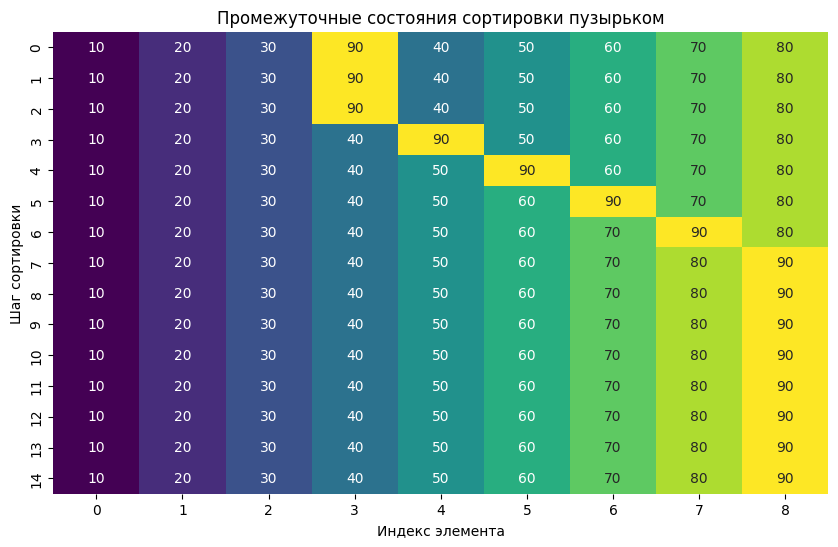

In [ ]:
arr = [10, 20, 30, 90, 40, 50, 60, 70, 80]
steps = bubble_sort(arr)

# Создаем матрицу для heatmap
matrix = np.array(steps)

# Построение heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='viridis', cbar=False)
plt.title('Промежуточные состояния сортировки пузырьком')
plt.xlabel('Индекс элемента')
plt.ylabel('Шаг сортировки')
plt.show()

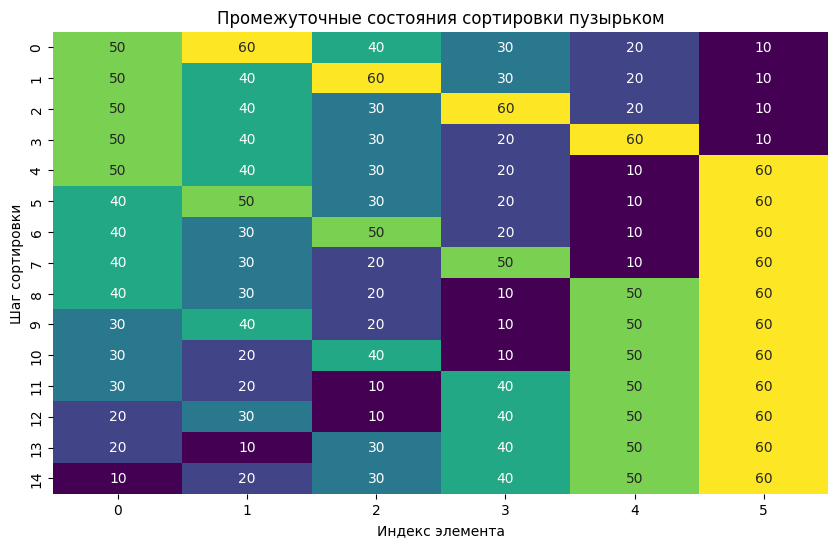

In [ ]:
arr = [60, 50, 40, 30, 20, 10]
steps = bubble_sort(arr)

# Создаем матрицу для heatmap
matrix = np.array(steps)

# Построение heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='viridis', cbar=False)
plt.title('Промежуточные состояния сортировки пузырьком')
plt.xlabel('Индекс элемента')
plt.ylabel('Шаг сортировки')
plt.show()

На визуализациях видно, что каждый следующий элемент действительно как будто "всплывает", меняясь на каждом шаге местами с меньшим соседом. Как было отмечено, алгоритм сортировки пузырьком прост, но его исполнение занимает много времени.

#### Сортировка слиянием

Алгоритм сортировки слиянием (Merge Sort) - это эффективный алгоритм сортировки, который использует принцип ["разделяй и властвуй"](https://education.yandex.ru/handbook/algorithms/article/razdelyaj-i-vlastvuj). Он разбивает массив на две равные (или почти равные) половины, сортирует каждую из половин, а затем объединяет их в отсортированный массив.

Шаги алгоритма сортировки слиянием:

1. Разделение: Исходный массив разделяется на две (почти) равные части.
2. Рекурсивная сортировка: Каждая из половин массива сортируется с использованием того же алгоритма слияния.
3. Слияние: Отсортированные половины массива объединяются в один отсортированный массив.
4. Основной шаг - это слияние двух отсортированных массивов. Это делается за линейное время.

Алгоритм сортировки слиянием  работает за время $O(n log n)$, где $n$ - количество элементов в массиве. Это делает его одним из самых эффективных алгоритмов сортировки для больших массивов данных.

In [ ]:
def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    # Разделение массива на две части
    mid = len(arr) // 2
    left_half = arr[:mid]
    right_half = arr[mid:]

    # Рекурсивная сортировка каждой из частей
    left_half = merge_sort(left_half)
    right_half = merge_sort(right_half)

    # Слияние отсортированных частей
    return merge(left_half, right_half)

def merge(left, right):
    result = []
    left_idx, right_idx = 0, 0

    # Сравниваем элементы и объединяем в отсортированный массив
    while left_idx < len(left) and right_idx < len(right):
        if left[left_idx] < right[right_idx]:
            result.append(left[left_idx])
            left_idx += 1
        else:
            result.append(right[right_idx])
            right_idx += 1

    # Добавляем оставшиеся элементы
    result.extend(left[left_idx:])
    result.extend(right[right_idx:])

    return result

In [ ]:
arr = [64, 34, 25, 12, 22, 11, 90]
sorted_arr = merge_sort(arr)
print(sorted_arr)

[11, 12, 22, 25, 34, 64, 90]


Давайте сравним время работы обеих сортировок.

  0%|          | 0/10 [00:00<?, ?it/s]

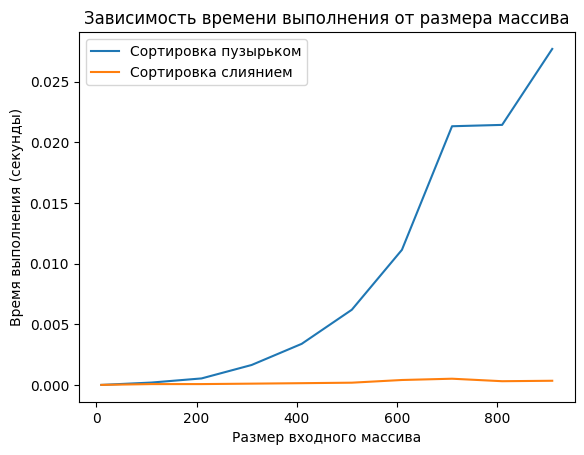

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import tqdm
from tqdm.auto import tqdm as tqdm

# Создаем массивы для хранения размеров входного массива и времени выполнения каждой функции
sizes = np.arange(10, 1000, 100)
bubble_sort_times = []
merge_sort_times = []

# Заполняем массивы времени выполнения
for size in tqdm(sizes):
    arr = np.random.randint(0, size*10, size)
    start_time = time.time()
    for _ in range(10):
      bubble_sort(arr)
    end_time = time.time()
    bubble_sort_times.append((end_time - start_time)/100)

    start_time = time.time()
    for _ in range(10):
      merge_sort(arr)
    end_time = time.time()
    merge_sort_times.append((end_time - start_time)/100)

# Построение графиков
plt.plot(sizes, bubble_sort_times, label='Сортировка пузырьком')
plt.plot(sizes, merge_sort_times, label='Сортировка слиянием')
plt.xlabel('Размер входного массива')
plt.ylabel('Время выполнения (секунды)')
plt.title('Зависимость времени выполнения от размера массива')
plt.legend()
plt.show()

Теория алгоритмов - это очень большая область. Если вам интересно подробнее разобраться в классических алгоритмах и структурах данных, а также в некоторых математических утверждениях, то рекомендуем книгу Томаса Кормена **"Алгоритмы: построение и анализ"**. Эта книга очень авторитетна в среде специалистов по теории алгоритмов.